# Computer Vision

## 0. Computer vision libraries in PyTorch

* [`torchvision`]
* `torchvision.datasets` - get datasets and data loading functions for computer vision here
* `torchvision.models` - get pretrained computer vision models that you can leverage for your own problems
* `torchvision.transforms` - functions for manipultaing your vision data (images) to be suitable for use with an ML model
* `torch.utils.data.Dataset` - base dataset class for PyTorch
* `torch.utils.data.DataLoader` - create a Python iterable over a dataset

In [110]:
import numpy as np
import torch
import torchvision
from torchvision import transforms, datasets, models
from torchvision.transforms import ToTensor
from torch import nn
import matplotlib.pyplot as plt
import plotly.express as px
from torch.utils.data import Dataset, DataLoader
from torchmetrics import Accuracy

In [2]:
print(torch.__version__)
print(torchvision.__version__)

2.5.1+cu121
0.20.1+cu121


In [85]:
print("CUDA dostępna:", torch.cuda.is_available())
print("Używane urządzenie:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

CUDA dostępna: True
Używane urządzenie: NVIDIA GeForce GTX 1660 Ti
cuda


## 1. Getting a dataset

The dataset we'll be using is a [FashionMNIST](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST) from torchvision.datasets

In [5]:
# Setup traning data

train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # do we want to the training dataset?
    download=True,
    transform=ToTensor(), # how do we want to transform the data?
    target_transform=None #  how do we want to transform the labels?
)

test_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=False, # do we want to the training dataset?
    download=True,
    transform=ToTensor(), # how do we want to transform the data?
    target_transform=None #  how do we want to transform the labels?
)

100.0%


Extracting data\FashionMNIST\raw\train-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to data\FashionMNIST\raw



100.0%


Extracting data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to data\FashionMNIST\raw



100.0%

Extracting data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to data\FashionMNIST\raw



In [6]:
len(train_data), len(test_data)

(60000, 10000)

In [10]:
image, label = train_data[0]

In [20]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [25]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [27]:
train_data.targets.unique()

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [31]:
print(f'Image shape: {image.shape} -> [color_channels, height, width]')
print(f'Image label: {class_names[label]}')

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image label: Ankle boot


### 1.2 Visualizing our data

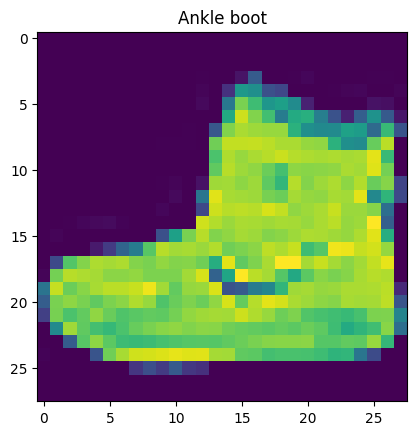

In [ ]:
plt.imshow(image.squeeze()) 
plt.title(class_names[label])
plt.show()


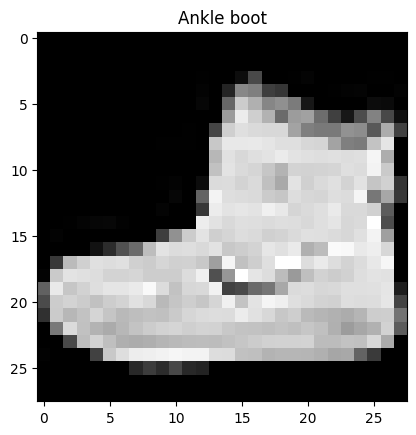

In [38]:
plt.imshow(image.squeeze(), cmap='grey') 
plt.title(class_names[label])
plt.show()


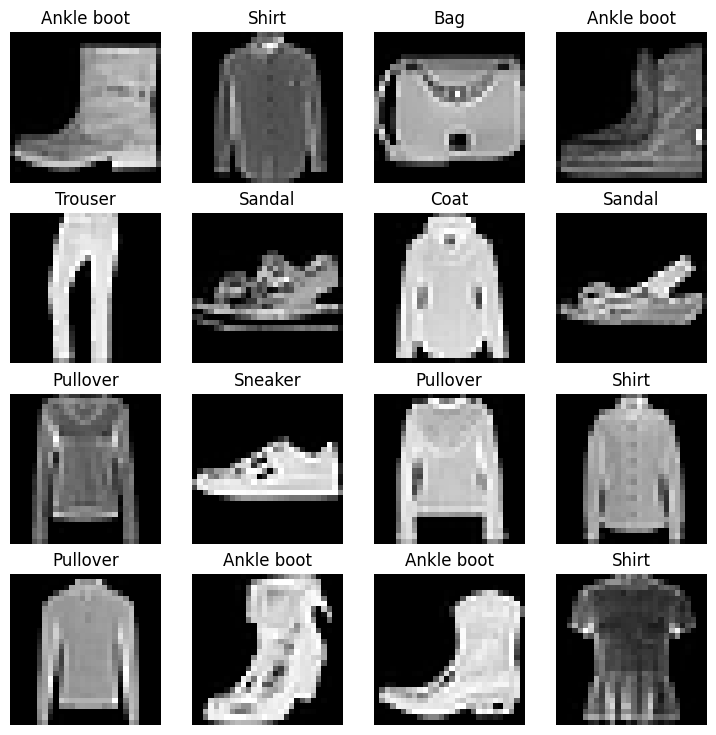

In [55]:
# Plot more images
torch.manual_seed(42)

fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4

for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap='grey')
    plt.title(class_names[label])
    plt.axis(False)

Do you think these items of clothing (images) could be modeled with pure linear lines? Or do you think we'll need non_linearities?

## 2. Prepare DataLoader

Right now, our data is in the form of PyTorch Datasets.

DataLoader turns our dataset into a Python iterable.

More specifically, we want to turn our data into batches (or mini-batches).

Why would we do this?

1. It is more computationally efficient, as in, your computer hardware may not be able to look (store in memory) at 60000 images in one hit. So we break it down to 32 images at a time (batch size of 32).
2. It gives our neural network more chances to update its gradients per epoch.

In [60]:
# Setup the batch size hyperparameter
batch_size = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=batch_size,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=batch_size,
    shuffle=False
)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1e11fb04a10>,
 <torch.utils.data.dataloader.DataLoader at 0x1e1204eb010>)

In [67]:
# Let's chech out what we've created

print(f'Dataloaders: {train_dataloader, test_dataloader}')
print(f'Length of train_dataloaer: {len(train_dataloader)} batches of {batch_size}...')
print(f'Length of train_dataloaer: {len(test_dataloader)} batches of {batch_size}...')

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001E11FB04A10>, <torch.utils.data.dataloader.DataLoader object at 0x000001E1204EB010>)
Length of train_dataloaer: 1875 batches of 32...
Length of train_dataloaer: 313 batches of 32...


In [74]:
# Check out what's inside the training dataloader

train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Img shape: torch.Size([1, 28, 28]), Label: 7, Label shape: torch.Size([])


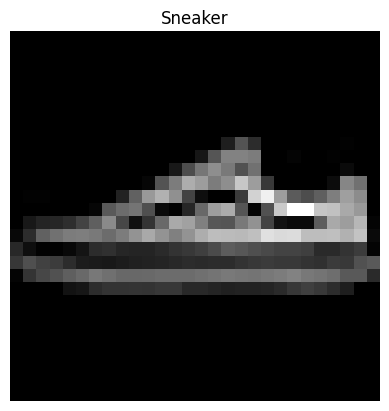

In [82]:
# SHow a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f'Img shape: {img.shape}, Label: {label}, Label shape: {label.shape}')

## 3. Model 0: Build a baseline model

When starting to build a series of machine learning modelling experiments, it's best pracice to start with a baseline model.

A baseline model is a simple model you will try and improve upow with subsequent models/experiments.

In other words: start simply and add complexity when necessary.

In [94]:
# Create a flatten layer

flatten_model = nn.Flatten()

# Get a single sample

x = train_features_batch[0]

# Flatten the sample

output = flatten_model(x)
x.shape, output.shape, output.squeeze().shape

(torch.Size([1, 28, 28]), torch.Size([1, 784]), torch.Size([784]))

In [95]:
class FashioMnistModelV0(nn.Module):
    def __init__(self,
                 input_shape:int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                      out_features=hidden_units),
            nn.Linear(in_features=hidden_units,
                      out_features=output_shape),
            nn.ReLU()
        ) 
    def forward(self, x):
        return self.layer_stack(x)

In [103]:
torch.manual_seed(42)

# Setup model with input parameters

model_0 = FashioMnistModelV0(
    input_shape=28**2,
    hidden_units=128,
    output_shape=len(class_names) #10
).to("cpu")

model_0

FashioMnistModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): Linear(in_features=128, out_features=10, bias=True)
    (3): ReLU()
  )
)

In [104]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0((dummy_x))

tensor([[0.0000, 0.0000, 0.0000, 0.0714, 0.0000, 0.0000, 0.0321, 0.0000, 0.1276,
         0.1425]], grad_fn=<ReluBackward0>)

In [105]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0195,  0.0034,  0.0302,  ..., -0.0030, -0.0317,  0.0128],
                      [-0.0107,  0.0221, -0.0158,  ..., -0.0121,  0.0042,  0.0318],
                      [-0.0106,  0.0342,  0.0240,  ...,  0.0091,  0.0174,  0.0041]])),
             ('layer_stack.1.bias',
              tensor([-8.6770e-04,  2.6513e-02,  2.4231e-02,  3.5641e-03, -3.2895e-02,
                       2.1752e-02,  3.3599e-02, -8.3219e-03, -8.0973e-03, -5.9837e-03,
                      -1.4779e-03,  3.3858e-02,  1.4686e-02, -3.0424e-02, -1.8899e-02,
                      -2.9557e-03, -1.8481e-02, -3.1352e-02,  1.0393e-02,  2.9328e-02,
                       7.0543e-03, -4.0150e-

### 3.1 Setup loss, optimizer and evaluation metrics

* Loss funciton - since we're workign with multi-class data, our loss function will be `nn.CrossEntropyLoss()`
* Optimizer - our optimizer `torch.optim.SGD()` 
* Evaluation metric - since we're working on a classification problem, let's see accuracy on a evaluation

In [112]:
import requests
from pathlib import Path

if Path('helper_functions.py').is_file():
    print('Exist')
else:
    print('Downlaoding')
    request = requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py')
    with open("helper_functions.py", 'wb') as f:
        f.write(request.content)

Downlaoding


In [113]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.01)

### 3.2 Creating a function to time our experiments

Machine learning is very experimental. 

Two of the main things you'll often want to track are:
1. Model's performance (loss and evaluation values)
2. How fast it runs

In [ ]:
from timeit import default_timer as timer

def print_train_time(start: float,
                     end: float,
                     device: torch.device=None):
    """ Prints difference between start and end time

    Args:
        start (float): start time
        end (float): end time
        device (torch.device, optional): _description_. Defaults to None.

    Returns:
        _type_: _description_
    """
    
    total_time = end - start
    print(f'Train time on {device}: {total_time:.3f} seconds')
    return total_time

In [119]:
start_time = timer()
# code...
end_time = timer()

print_train_time(start_time, end_time, device)

Train time on cuda: 0.000 seconds


3.0499999411404133e-05